# Evaluasi dan Analisis RNN
Notebook ini difokuskan hanya untuk mengevaluasi model **RNN** sesuai rubrik tugas. Hasil dari notebook ini akan digunakan untuk dibandingkan dengan model LSTM di dokumen laporan utama.

In [2]:
import os
import sys
import json
import time
import random
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from nltk.translate.meteor_score import meteor_score
!python -m nltk.downloader wordnet


PROJECT_ROOT = os.path.abspath(os.path.join(os.path.abspath(""), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.rnn.RNNKeras import RNNKeras
from src.rnn.RNNScratch import RNNScratch

metadata_path = os.path.join(PROJECT_ROOT, "outputs", "vocab", "metadata.json")
vocab_path = os.path.join(PROJECT_ROOT, "outputs", "vocab", "vocab.json")
test_txt = os.path.join(PROJECT_ROOT, "data", "Flickr_8k.testImages.txt")
images_dir = os.path.join(PROJECT_ROOT, "data", "Images")
captions_file = os.path.join(PROJECT_ROOT, "data", "captions.txt")
models_dir = os.path.join(PROJECT_ROOT, "models")
output_dir = os.path.join(PROJECT_ROOT, "outputs")

with open(vocab_path, "r") as f:
    word_to_idx = json.load(f)
idx_to_word = {str(idx): word for word, idx in word_to_idx.items()}

with open(test_txt, "r") as f:
    test_images = [line.strip() for line in f if line.strip()]
sample_images = [img for img in test_images if os.path.exists(os.path.join(images_dir, img))]

def load_captions(captions_file):
    image_captions = {}
    with open(captions_file, "r", encoding="utf-8") as f:
        next(f)
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(",", 1)
            if len(parts) == 2:
                img, cap = parts
                if img not in image_captions:
                    image_captions[img] = []
                image_captions[img].append(cap)
    return image_captions

image_captions = load_captions(captions_file)

# 100 untuk testing cepat. Ganti menjadi len(sample_images) untuk evaluasi akhir.
eval_images = sample_images[:100] 
references = []
meteor_references = []
for img in eval_images:
    img_refs = []
    meteor_refs = []
    for cap in image_captions[img]:
        words = cap.lower().replace(".", "").replace(",", "").split()
        img_refs.append(words)
        meteor_refs.append(" ".join(words))
    references.append(img_refs)
    meteor_references.append(meteor_refs)


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Alfansya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\Alfansya\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## A. Evaluasi Variasi Jumlah Layer dan Hidden State (RNN)
Mengevaluasi BLEU-4 dan METEOR score, serta menampilkan grafik training dan validation loss tiap epoch untuk semua variasi RNN.

--- Grafik Training dan Validation Loss Tiap Epoch (RNN) ---


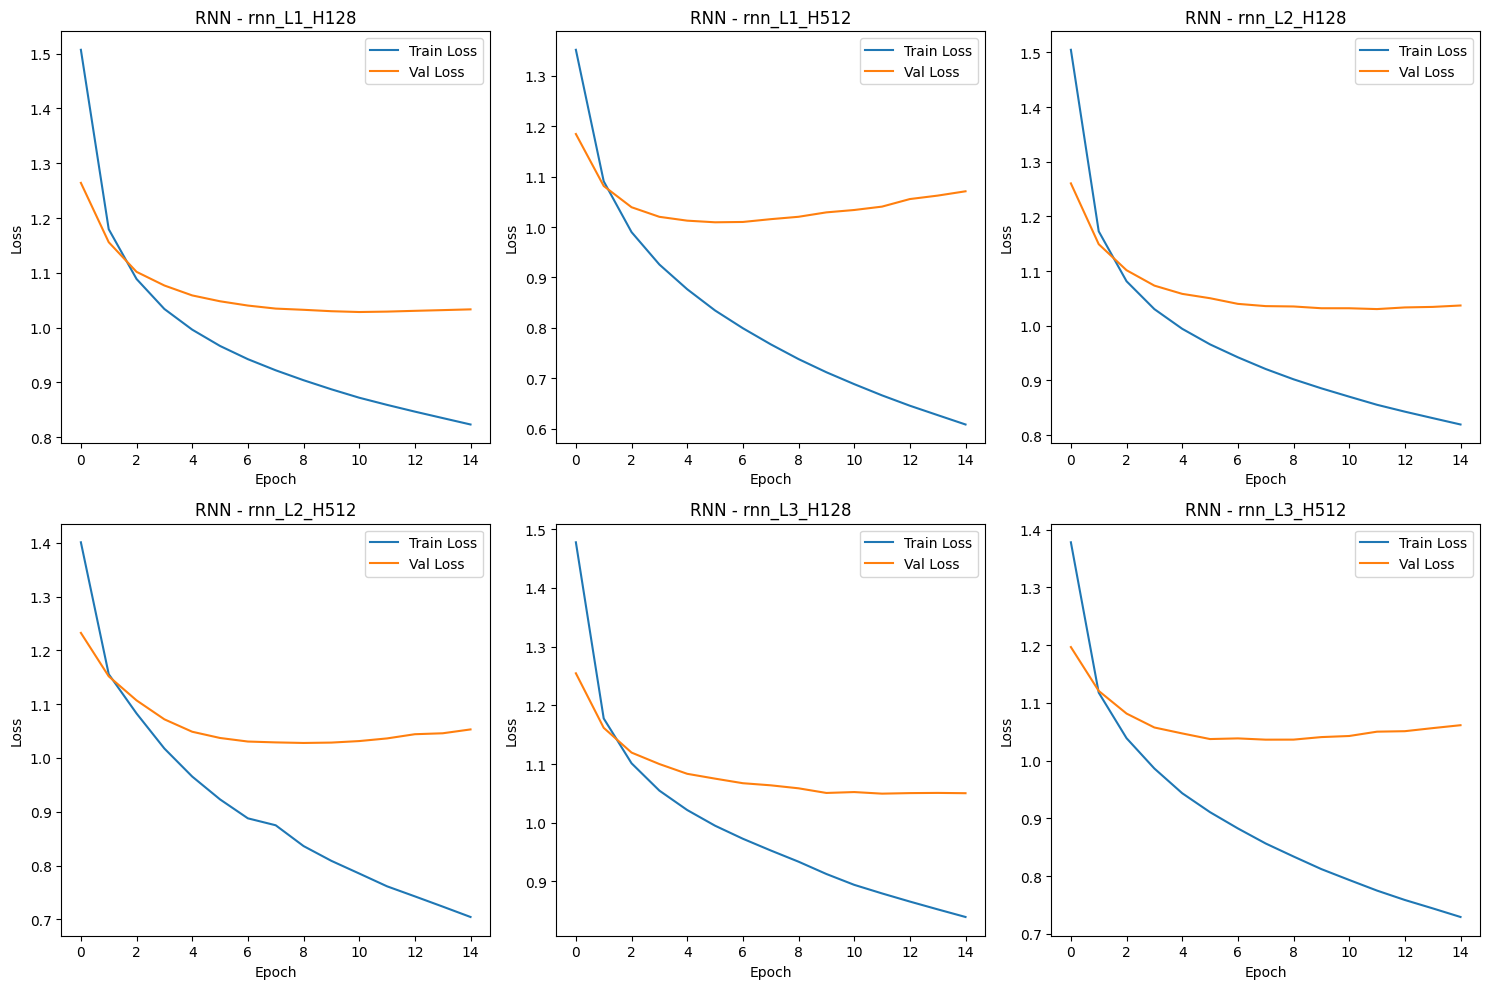

In [3]:
def plot_history(architecture):
    arch_dir = os.path.join(models_dir, architecture)
    if not os.path.exists(arch_dir):
        print(f"Folder {arch_dir} belum ada.")
        return
        
    histories = glob.glob(os.path.join(arch_dir, "*", "history.json"))
    if not histories:
        print(f"Belum ada file history.json di dalam {arch_dir}.")
        return
        
    plt.figure(figsize=(15, 10))
    for i, hist_file in enumerate(sorted(histories)):
        config_name = os.path.basename(os.path.dirname(hist_file))
        with open(hist_file, 'r') as f:
            h = json.load(f)
            
        plt.subplot(2, 3, i+1)
        plt.plot(h['loss'], label='Train Loss')
        plt.plot(h['val_loss'], label='Val Loss')
        plt.title(f"{architecture.upper()} - {config_name}")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

print("--- Grafik Training dan Validation Loss Tiap Epoch (RNN) ---")
plot_history("rnn")


Mengevaluasi rnn_L1_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L1_H512...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L2_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L2_H512...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L3_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L3_H512...
Encoder: INCEPTIONV3 — output dim: 2048

--- Tabel Hasil Evaluasi RNN ---
     config    bleu4   meteor   time_s
rnn_L1_H128 0.046569 0.225452 0.299800
rnn_L1_H512 0.033290 0.210272 0.325629
rnn_L2_H128 0.033473 0.198715 0.271495
rnn_L2_H512 0.039787 0.195868 0.301976
rnn_L3_H128 0.042764 0.229290 0.217418
rnn_L3_H512 0.040884 0.221053 0.336624


C:\Users\Alfansya\AppData\Local\Temp\ipykernel_32696\193354255.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rnn, x="config", y="bleu4", ax=axes[0], palette="Blues")
C:\Users\Alfansya\AppData\Local\Temp\ipykernel_32696\193354255.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rnn, x="config", y="meteor", ax=axes[1], palette="Oranges")


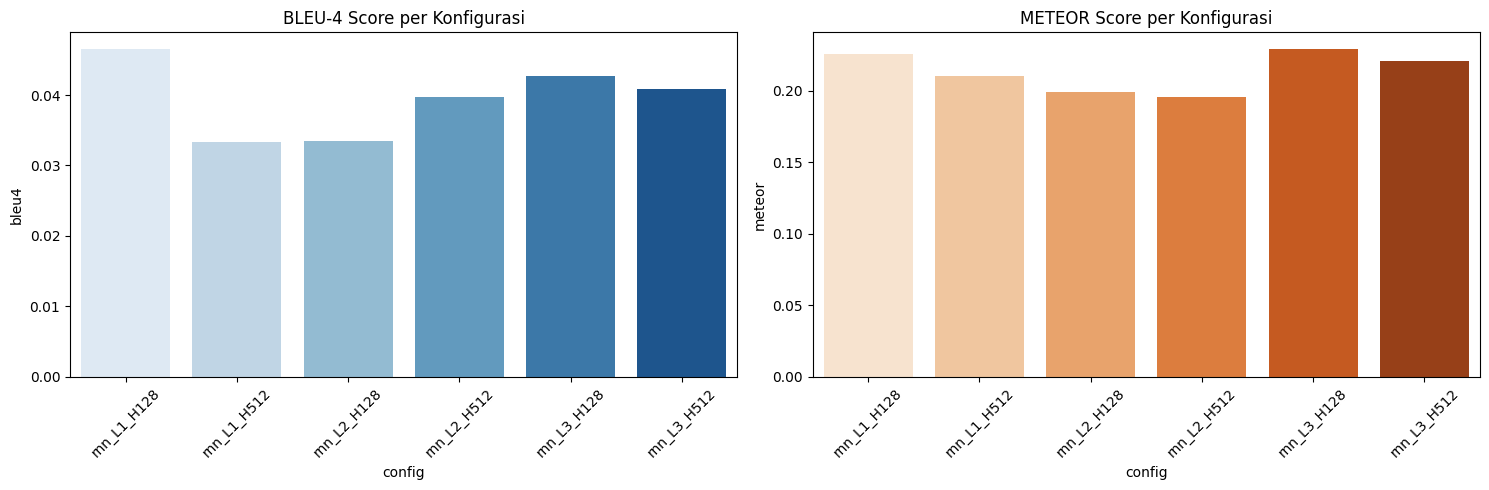

In [4]:
# Evaluasi BLEU-4 dan METEOR
def evaluate_all_variations(architecture):
    arch_dir = os.path.join(models_dir, architecture)
    if not os.path.exists(arch_dir): return []
    
    configs = [d for d in os.listdir(arch_dir) if os.path.isdir(os.path.join(arch_dir, d))]
    results = []
    
    for config in sorted(configs):
        model_path = os.path.join(arch_dir, config, f"{config}.keras")
        if not os.path.exists(model_path): continue
            
        print(f"Mengevaluasi {config}...")
        try:
            captioner = RNNScratch(model_path, metadata_path)
        except Exception as e:
            print(f"Gagal memuat {config}: {e}")
            continue
            
        hypotheses = []
        meteor_scores = []
        start_time = time.time()
        
        for i, img in enumerate(eval_images):
            img_path = os.path.join(images_dir, img)
            caption = captioner.generate_caption(img_path, idx_to_word)
            words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
            hypotheses.append(words)
            m_score = meteor_score(references[i], words)
            meteor_scores.append(m_score)
            
        total_time = time.time() - start_time
        bleu4 = corpus_bleu(references, hypotheses)
        avg_meteor = np.mean(meteor_scores)
        
        results.append({
            "config": config,
            "bleu4": bleu4,
            "meteor": avg_meteor,
            "time_s": total_time / len(eval_images)
        })
    return results

rnn_results = evaluate_all_variations("rnn")

if rnn_results:
    df_rnn = pd.DataFrame(rnn_results)
    
    print("\n--- Tabel Hasil Evaluasi RNN ---")
    print(df_rnn[['config', 'bleu4', 'meteor', 'time_s']].to_string(index=False))
    
    # Plotting Grafik Bar
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=df_rnn, x="config", y="bleu4", ax=axes[0], palette="Blues")
    axes[0].set_title("BLEU-4 Score per Konfigurasi")
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.barplot(data=df_rnn, x="config", y="meteor", ax=axes[1], palette="Oranges")
    axes[1].set_title("METEOR Score per Konfigurasi")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


**Kesimpulan Bagian A (Pengaruh Jumlah Layer dan Ukuran Hidden State RNN):**
- Berdasarkan grafik training loss dan validation loss pada setiap epoch, peningkatan ukuran hidden state dari 128 menjadi 512 secara konsisten mempercepat dan memperparah terjadinya gejala overfitting. Pada seluruh variasi dengan kapasitas H512 (rnn_L1_H512, rnn_L2_H512, dan rnn_L3_H512), kurva validation loss mencapai titik minimum lokal yang optimal di sekitar epoch 5 hingga 6, sebelum akhirnya berbalik naik secara signifikan sementara training loss terus menurun landai. Sebaliknya, penambahan jumlah layer pada model dengan ukuran hidden state kecil (H128) mampu mempertahankan stabilitas kurva validation loss sehingga tetap landai hingga akhir epoch. Hal ini menunjukkan bahwa peningkatan dimensi hidden state secara drastis meningkatkan kapasitas penayangan parameter model secara berlebihan, membuat model cenderung menghafal deretan teks pada data training alih-alih mempelajari generalisasi fitur spasial gambar.
- Hasil pengujian membuktikan bahwa penambahan jumlah layer recurrent maupun pembesaran ukuran hidden units menjadi 512 tidak menjamin perolehan skor BLEU-4 dan METEOR yang lebih tinggi.

## B. Perbandingan Keras vs Scratch
Membandingkan skor dan waktu eksekusi Keras vs From Scratch pada arsitektur RNN terbaik.

In [5]:
if rnn_results:
    best_rnn = max(rnn_results, key=lambda x: x["bleu4"])
    best_model_name = best_rnn["config"]
    print(f"Menggunakan Model RNN Terbaik: {best_model_name}\n")
    
    best_model_path = os.path.join(models_dir, "rnn", best_model_name, f"{best_model_name}.keras")
    
    keras_model = RNNKeras(best_model_path, metadata_path)
    scratch_model = RNNScratch(best_model_path, metadata_path)
    
    keras_scratch_res = []
    
    for name, model in [("Keras", keras_model), ("Scratch", scratch_model)]:
        hypotheses = []
        start_time = time.time()
        for img in eval_images:
            img_path = os.path.join(images_dir, img)
            caption = model.generate_caption(img_path, idx_to_word)
            words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
            hypotheses.append(words)
            
        t = (time.time() - start_time) / len(eval_images)
        b4 = corpus_bleu(references, hypotheses)
        keras_scratch_res.append({"Implementasi": name, "BLEU-4": b4, "Waktu per Img (detik)": t})
        
    df_ks = pd.DataFrame(keras_scratch_res)
    print(df_ks.to_string(index=False))
else:
    print("Model RNN belum dievaluasi.")


Menggunakan Model RNN Terbaik: rnn_L1_H128

Encoder: INCEPTIONV3 — output dim: 2048
Encoder: INCEPTIONV3 — output dim: 2048
Implementasi   BLEU-4  Waktu per Img (detik)
       Keras 0.046569               1.538627
     Scratch 0.046569               0.202360


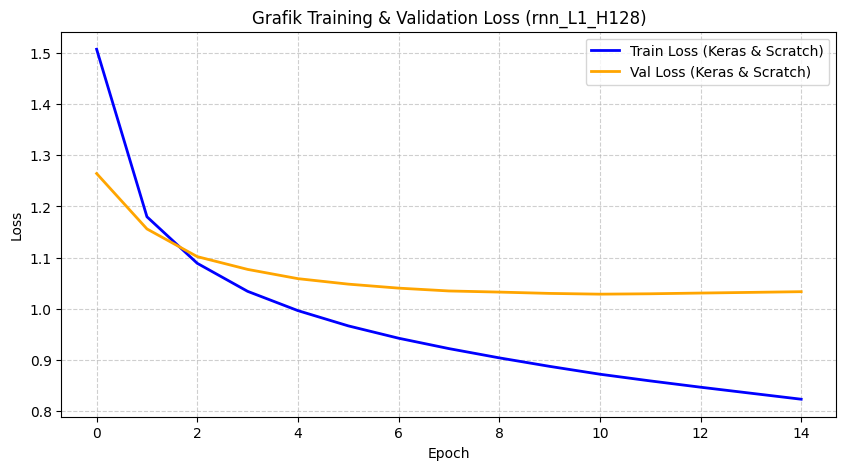

In [10]:
if rnn_results:
    import json
    
    history_path = os.path.join(models_dir, "rnn", best_model_name, "history.json")
    with open(history_path, 'r') as f:
        h = json.load(f)
        
    plt.figure(figsize=(10, 5))
    plt.plot(h['loss'], label='Train Loss (Keras & Scratch)', color='blue', linewidth=2, linestyle='-')
    plt.plot(h['val_loss'], label='Val Loss (Keras & Scratch)', color='orange', linewidth=2, linestyle='-')
    
    plt.title(f"Grafik Training & Validation Loss ({best_model_name})")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


**Kesimpulan Bagian B (Keras vs Scratch):**
- Berdasarkan hasil pengujian, skor BLEU-4 yang dihasilkan oleh implementasi Keras dan from scratch menunjukkan nilai yang identik, yaitu sebesar 0.046569. Kesamaan ini karena modul from scratch memuat secara langsung keseluruhan matriks bobot dan vektor bias dari model Keras yang telah dilatih, seluruh kalkulasi mengikuti formula yang sama. Akibatnya, distribusi probabilitas kata yang dikeluarkan pada setiap timestep menghasilkan output yang sama persis
- Berdasarkan data hasil pengujian, implementasi from scratch lebih cepat dibandingkan dengan Keras. Keras/TensorFlow mengalami beban overhead framework yang sangat besar pada setiap langkah looping akibat adanya proses pengecekan grafik eksekusi, alokasi tensor internal, serta jalur abstraksi layer yang kompleks. Sebaliknya, implementasi from scratch dengan NumPy langsung mengeksekusi operasi array di level bahasa C secara raw dan minimalis tanpa dibebani oleh manajemen arsitektur deep learning framework, sehingga menghasilkan waktu pemrosesan yang jauh lebih efisien pada CPU.

## C. Analisis Kualitatif Decoder RNN (Untuk Persiapan Perbandingan dengan LSTM)
Menampilkan skor terbaik RNN dan memunculkan 10 contoh gambar dengan skor bervariasi (Tinggi, Sedang, Rendah) beserta caption RNN dan Ground Truth. Hasil dari bagian ini akan dibawa ke laporan final untuk disandingkan dengan LSTM.

  DATA DECODER RNN TERBAIK (rnn_L1_H128)
- BLEU-4 Score          : 0.0466
- METEOR Score          : 0.2255
- Waktu Inferensi / Img : 0.2998 detik


C:\Users\Alfansya\AppData\Roaming\Python\Python313\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\Alfansya\AppData\Roaming\Python\Python313\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\Users\Alfansya\AppData\Roaming\Python\Python313\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Con

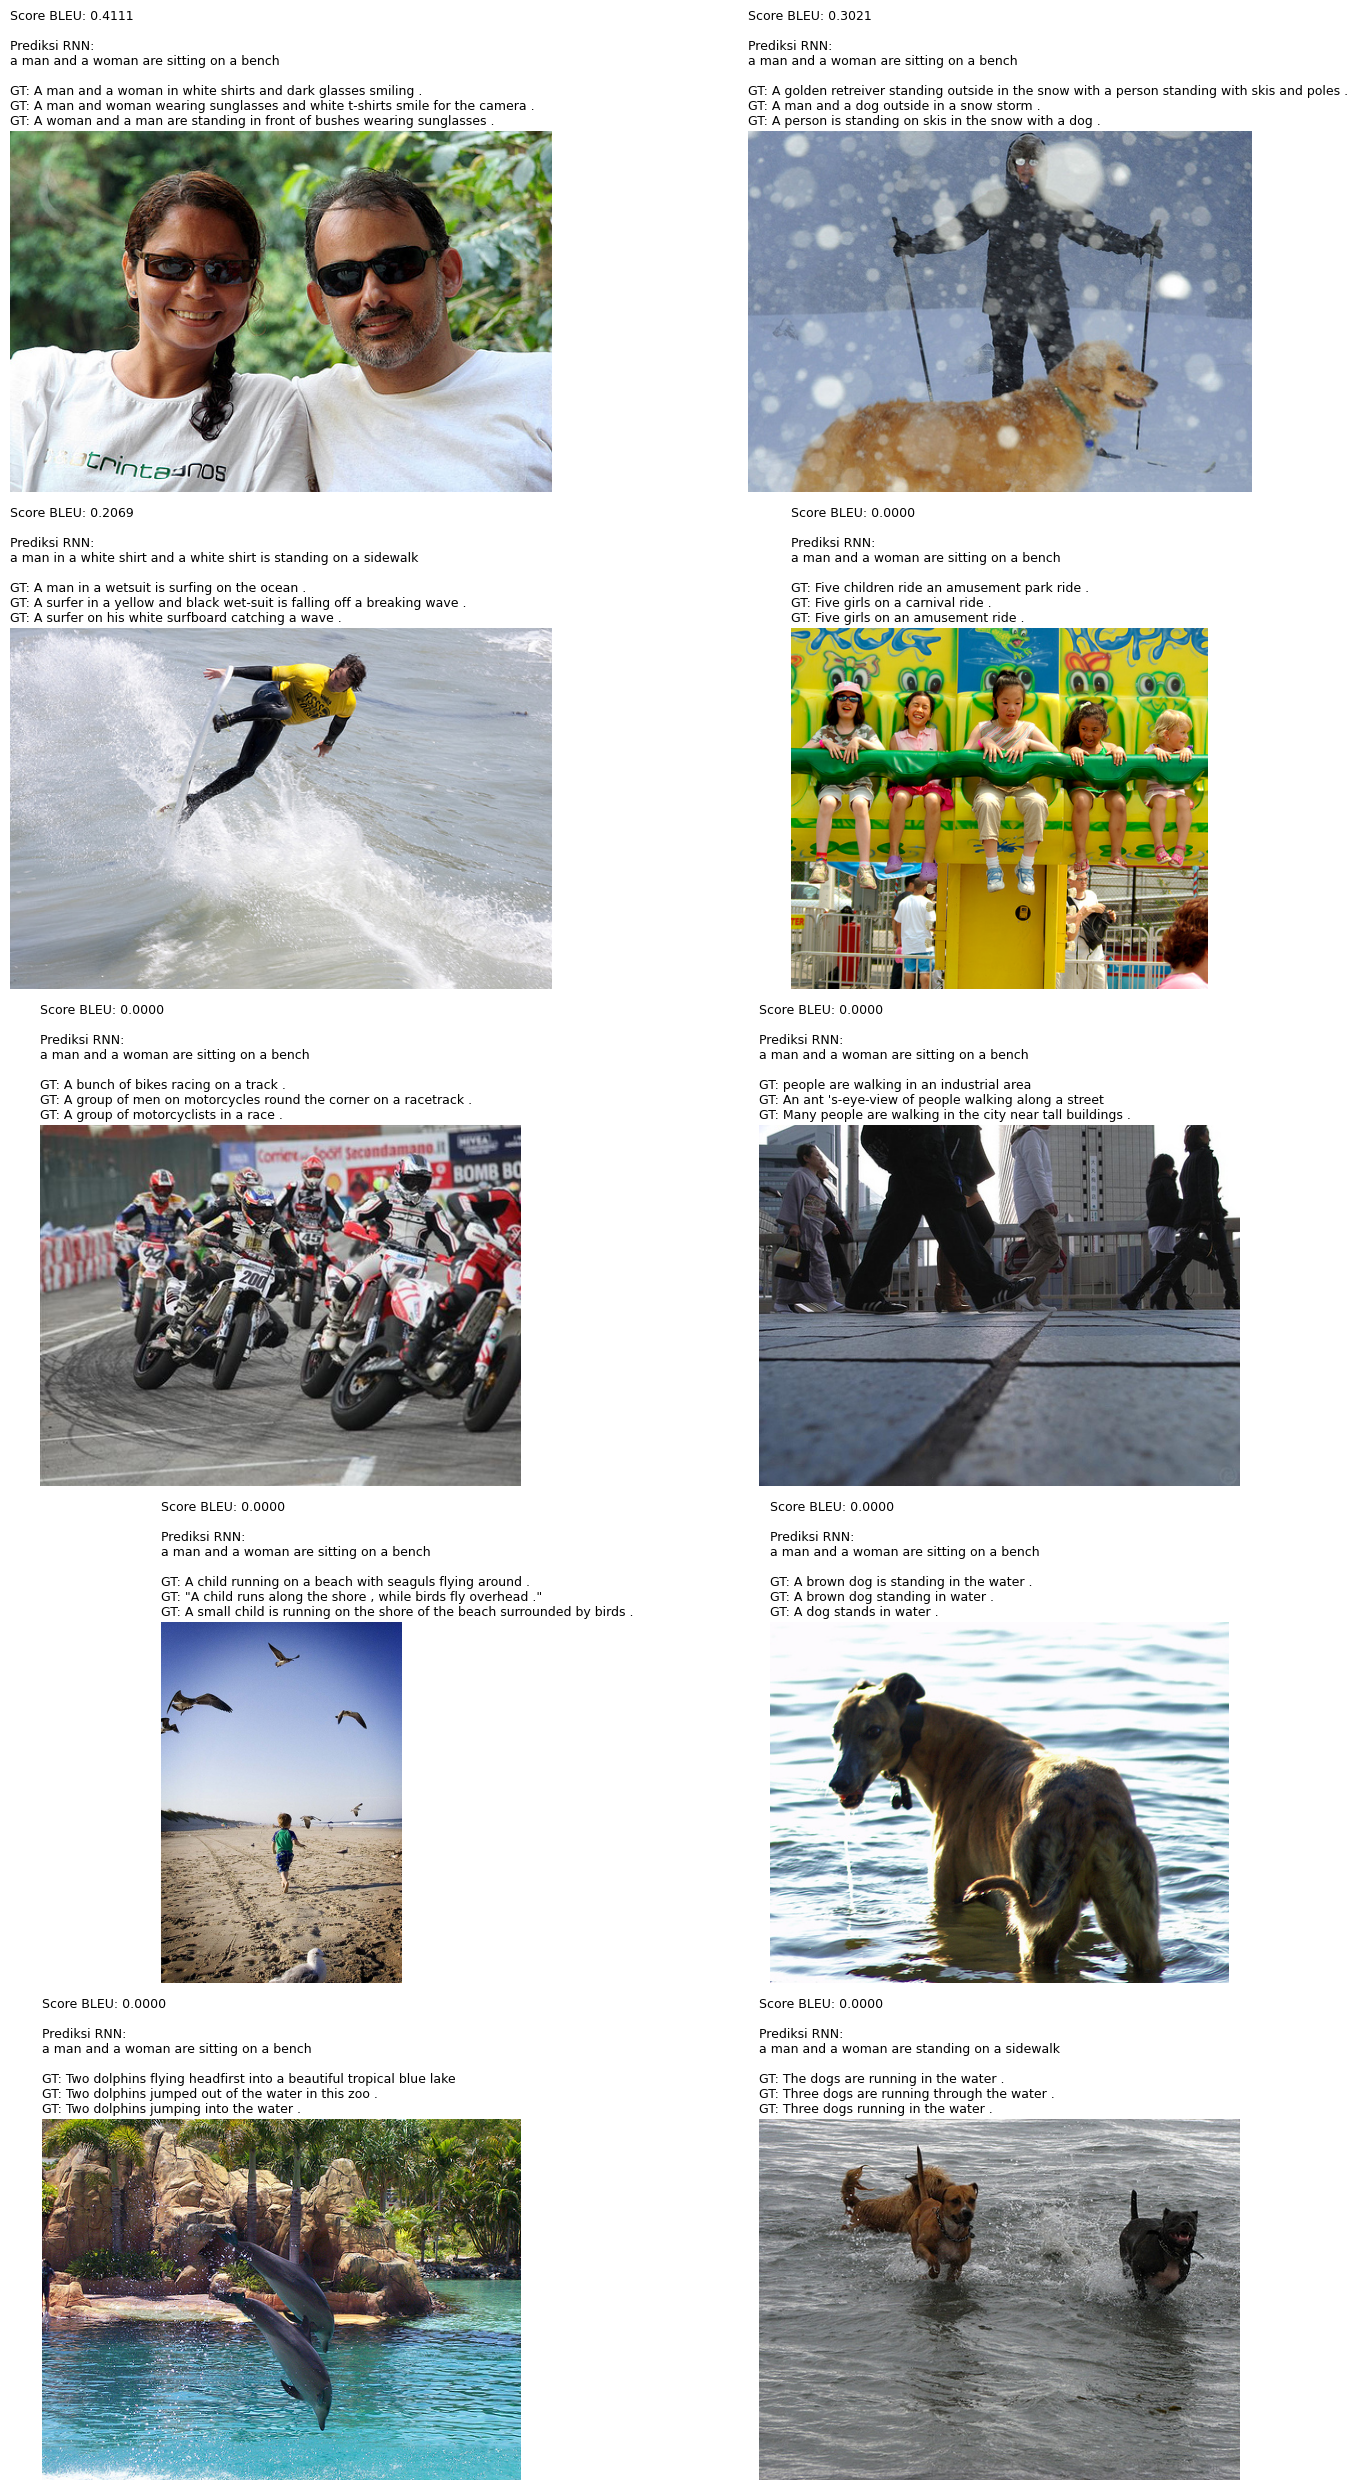

In [6]:
if rnn_results:
    print("="*60)
    print(f"  DATA DECODER RNN TERBAIK ({best_rnn['config']})")
    print("="*60)
    print(f"- BLEU-4 Score          : {best_rnn['bleu4']:.4f}")
    print(f"- METEOR Score          : {best_rnn['meteor']:.4f}")
    print(f"- Waktu Inferensi / Img : {best_rnn['time_s']:.4f} detik")
    print("="*60)

    
    qualitative_data = []
    for i, img in enumerate(eval_images):
        img_path = os.path.join(images_dir, img)
        caption = keras_model.generate_caption(img_path, idx_to_word) # Pakai Keras agar cepat
        words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
        
        # NLTK sentence_bleu requires list of list of words for references
        score = sentence_bleu(references[i], words, weights=(0.25, 0.25, 0.25, 0.25))
        
        qualitative_data.append({
            "img_name": img,
            "path": img_path,
            "pred": " ".join(words),
            "gt": image_captions[img][:3], # Ambil 3 contoh GT
            "score": score
        })
        
    # Urutkan berdasarkan skor
    qualitative_data.sort(key=lambda x: x["score"], reverse=True)
    
    # Ambil 3 tinggi, 4 sedang (tengah), 3 rendah
    mid_idx = len(qualitative_data) // 2
    samples_to_show = qualitative_data[:3] + qualitative_data[mid_idx-2 : mid_idx+2] + qualitative_data[-3:]
    
    # Plotting 10 Gambar
    fig, axes = plt.subplots(5, 2, figsize=(15, 25))
    axes = axes.flatten()
    
    for ax, item in zip(axes, samples_to_show):
        img_data = mpimg.imread(item["path"])
        ax.imshow(img_data)
        ax.axis('off')
        
        # Susun teks
        gt_text = "\n".join([f"GT: {gt}" for gt in item["gt"]])
        title = f"Score BLEU: {item['score']:.4f}\n\nPrediksi RNN:\n{item['pred']}\n\n{gt_text}"
        ax.set_title(title, fontsize=9, loc='left', wrap=True)
        
    plt.tight_layout()
    plt.show()


Score dan waktu eksekusi decoder RNN (rnn_L1_H128)
- BLEU-4 Score          : 0.0466
- METEOR Score          : 0.2255
- Waktu Inferensi / Img : 0.2998 detik

**Pola Keluaran RNN & Analisis Vanishing Gradient (Bahan Laporan):**
- Model secara konstan membangkitkan kalimat yang hampir sama untuk objek yang sepenuhnya berbeda. Kalimat "a man and a woman are sitting on a bench" muncul sebagai prediksi untuk gambar anjing di atas salju, anak-anak di wahana bermain, balapan motor, kerumunan orang berjalan, anak kecil di pantai, hingga lumba-lumba di kolam. Model mengalami kegagalan total dalam membedakan fitur dan cenderung mengeluarkan sekuens dominan (safe prediction) yang paling sering muncul pada dataset latih.
- Fitur gambar hanya dimasukkan di awal (t = -1). Setiap kali model memproses kata baru, memori ($h_t$) diperbarui menggunakan fungsi $\tanh$. Saat proses training, turunan dari fungsi $\tanh$ yang bernilai kecil ($<1$) dikalikan secara berulang kali sepanjang kalimat. Hal ini membuat nilai gradien mengecil secara drastis hingga habis (mendekati nol) sebelum sempat mundur sampai ke langkah awal. Karena gradiennya hilang, bobot RNN ($W_{hh}$) gagal mempelajari hubungan jangka panjang. Akibatnya, baru beberapa langkah kata, SimpleRNN sudah lupa total dengan isi gambar. Model kehilangan arah dan tidak lagi mendeskripsikan gambar, melainkan hanya menebak-nebak kata berikutnya secara asal berdasarkan satu atau dua kata terakhir yang baru saja dibuat.

## D. Pengaruh Panjang Maksimum Caption
Membandingkan pengaruh pembatasan panjang kalimat (`max_length` = 10, 20, 30) terhadap kualitas (BLEU-4 score).

 Max Length  BLEU-4 Score
         10      0.052188
         20      0.046569
         30      0.046569


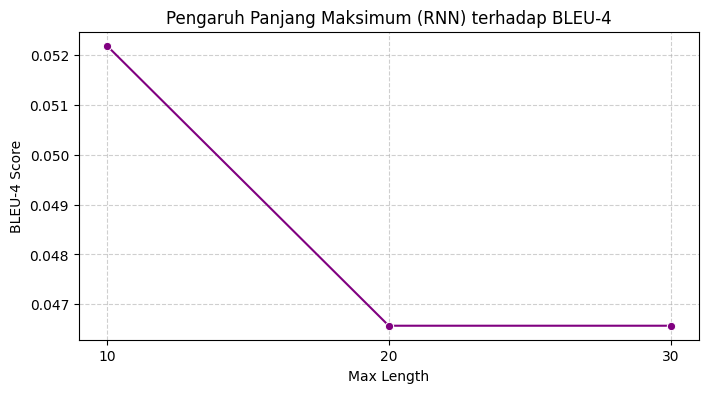

In [7]:
if rnn_results:
    max_lengths = [10, 20, 30]
    len_results = []
    
    for max_len in max_lengths:
        hypotheses = []
        for img in eval_images:
            img_path = os.path.join(images_dir, img)
            caption = keras_model.generate_caption(img_path, idx_to_word, max_len=max_len)
            words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
            hypotheses.append(words)
            
        b4 = corpus_bleu(references, hypotheses)
        len_results.append({"Max Length": max_len, "BLEU-4 Score": b4})
        
    df_len = pd.DataFrame(len_results)
    print(df_len.to_string(index=False))
    
    plt.figure(figsize=(8,4))
    sns.lineplot(data=df_len, x="Max Length", y="BLEU-4 Score", marker="o", color="purple")
    plt.title("Pengaruh Panjang Maksimum (RNN) terhadap BLEU-4")
    plt.xticks(max_lengths)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


**Kesimpulan Pengaruh Panjang Maksimum:**
- Saat max_length kecil (10) Skor BLEU-4  mencapai titik tertinggi karena pembatasan kalimat yang pendek mencegah SimpleRNN mengalami looping kata atau menebak captioin dengan asal akibat efek vanishing gradient. Saat max_length diperpanjang (20 dan 30) Skor BLEU-4 mengalami penurunan dan nilainya stagnan, membuktikan bahwa pada timestep ke-20, model RNN sudah selesai membangkitkan kalimat amannya atau sudah terjebak dalam perulangan kata yang tak berujung. Alhasil, menaikkan batas hingga 30 tidak mengubah apa pun karena kualitas kalimatnya sudah rusak sejak timestep sebelumnya.